In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
import scanpy as sc
import pandas as pd
import numpy as np
import torch
import dgl
import random
from scipy.sparse import csr_matrix
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics.cluster import normalized_mutual_info_score
import os

In [5]:
import so as so

In [6]:
seed = 42
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
dgl.random.seed(seed)

In [7]:
sc.set_figure_params(dpi=150, figsize=(2, 2), frameon=False)    # TODO 是否画边框

# load data

In [8]:
files = os.listdir('./soDGVAE_dataset/dataset/6_development_mouse_embryo_stereo/')
files

['E16.5_E1S1.MOSTA.h5ad',
 'E10.5_E1S1.MOSTA.h5ad',
 'E12.5_E1S1.MOSTA.h5ad',
 'E13.5_E1S1.MOSTA.h5ad',
 'E9.5_E1S1.MOSTA.h5ad',
 'E18.5_E1S1.MOSTA.h5ad',
 'E14.5_E1S1.MOSTA.h5ad',
 'E11.5_E1S1.MOSTA.h5ad',
 'E10.5_E1S3.MOSTA.h5ad',
 'E15.5_E1S1.MOSTA.h5ad']

In [9]:
files = [
 'E9.5_E1S1.MOSTA.h5ad',
     'E10.5_E1S3.MOSTA.h5ad',
     'E11.5_E1S1.MOSTA.h5ad',
     'E12.5_E1S1.MOSTA.h5ad',
     'E13.5_E1S1.MOSTA.h5ad',
     'E14.5_E1S1.MOSTA.h5ad',
     'E15.5_E1S1.MOSTA.h5ad',
    'E16.5_E1S1.MOSTA.h5ad',
 'E18.5_E1S1.MOSTA.h5ad',
]

In [10]:
data_list = [sc.read_h5ad(f'/home/gzh/projects2/benchmark/dataset/6_development_mouse_embryo_stereo/{file}') for file in files]
data_list

[AnnData object with n_obs × n_vars = 5913 × 25568
     obs: 'annotation', 'batch'
     var: 'n_cells'
     uns: 'annotation_colors'
     obsm: 'spatial'
     varm: 'PCs',
 AnnData object with n_obs × n_vars = 18670 × 25647
     obs: 'annotation'
     var: 'n_cells'
     obsm: 'spatial',
 AnnData object with n_obs × n_vars = 30124 × 26854
     obs: 'annotation', 'batch'
     var: 'n_cells'
     uns: 'annotation_colors'
     obsm: 'spatial'
     varm: 'PCs',
 AnnData object with n_obs × n_vars = 51365 × 27810
     obs: 'annotation', 'batch'
     var: 'n_cells'
     uns: 'annotation_colors'
     obsm: 'spatial'
     varm: 'PCs',
 AnnData object with n_obs × n_vars = 77369 × 28408
     obs: 'annotation', 'batch'
     var: 'n_cells'
     uns: 'annotation_colors'
     obsm: 'spatial'
     varm: 'PCs',
 AnnData object with n_obs × n_vars = 102519 × 28463
     obs: 'annotation', 'batch'
     var: 'n_cells'
     uns: 'annotation_colors'
     obsm: 'spatial'
     varm: 'PCs',
 AnnData object wi

In [11]:
batch_names = files

In [12]:
data_list[0].obs

,annotation,batch
cell_name,,
147_104,Cavity,E9
147_105,Cavity,E9
147_106,Cavity,E9
147_107,Cavity,E9
147_108,Mesenchyme,E9
...,...,...
253_110,Cavity,E9
253_111,Cavity,E9
253_112,Cavity,E9


In [13]:
batch_key = 'batch'
adata = so.pp.process_adata(data_list, label=batch_key, keys=batch_names, n_top_features=3000, target_sum=1e4)
adata

AnnData object with n_obs × n_vars = 736401 × 3000
    obs: 'original_index', 'spot_quality', 'batch'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'log1p', 'mu_bg', 'std_bg'
    obsm: 'spatial'
    layers: 'counts', 'norm_log'

In [ ]:
batch_key = 'batch'
adata = so.pp.process_adata(data_list, label=batch_key, keys=batch_names, n_top_features=2000, target_sum=1e4)
adata

In [14]:
rad_cutoff_list = [0] * len(data_list)
adata, g = so.pp.process_graph(adata, data_list, cutoff_list=rad_cutoff_list, model='KNN')

cal spatial net in data_list
------Calculating spatial graph...
The graph contains 0 edges, 5913 cells.
0.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 0 edges, 18670 cells.
0.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 0 edges, 30124 cells.
0.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 0 edges, 51365 cells.
0.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 0 edges, 77369 cells.
0.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 0 edges, 102519 cells.
0.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 0 edges, 113350 cells.
0.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 0 edges, 121767 cells.
0.0000 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 0 e

In [15]:
path_results = f'./log/integration/'

In [16]:
adata_int = so.model.DGVAE(adata=adata,
                            n_epoch=5,
                            batch_size=1024,
                            verbose=False,
                            gpu=0,
                            random_seed=42,
                            output_dir=path_results,
                            num_heads=2,
                            h_dim=16,
                            reconstruct_loss='orig',
                            alpha_mmd=0,
                            graph_loss=False,
                            )

clip
reconstruct_loss == orig


Epochs: 100%|█| 5/5 [01:58<00:00, 23.67s/it, recon_loss=248.1280, kl_loss=11.3680, mmd2=0.0000, graph_loss=0.0000, lr: 0
Infer latent: 100%|██████████████████████████████████████████████████████████████████| 720/720 [00:06<00:00, 105.28it/s]


In [17]:
del adata_int.uns['adj']

In [18]:
adata_int.write_h5ad(f'{path_results}adata_int.h5ad', compression='gzip')

In [1]:
import scanpy as sc
import cupy as cp
import time
import rapids_singlecell as rsc
import warnings
warnings.filterwarnings("ignore")

/home/gzh/anaconda3/envs/rapids_singlecell/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import rmm
from rmm.allocators.cupy import rmm_cupy_allocator
rmm.reinitialize(
    managed_memory=False,  # Allows oversubscription
    pool_allocator=False,  # default is False
    devices=0,  # GPU device IDs to register. By default registers only GPU 0.
)
cp.cuda.set_allocator(rmm_cupy_allocator)

In [3]:
import numpy as np
import scanpy as sc
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.neighbors import NearestNeighbors

def compute_ARI(adata, anno_key, pred_key):
    return adjusted_rand_score(adata.obs[anno_key], adata.obs[pred_key])

def compute_NMI(adata, anno_key, pred_key):
    return normalized_mutual_info_score(adata.obs[anno_key], adata.obs[pred_key])

In [4]:
sc.set_figure_params(dpi=150, figsize=(2, 2), frameon=False)    # TODO 是否画边框

In [5]:
def kmeans_cluster(adata, n_clusters=10, used_embedding='X_pca', mode='KMeans', key_add='kmeans'):
    from sklearn.cluster import KMeans, MiniBatchKMeans
    if mode == 'KMeans':
        model = KMeans(n_clusters=n_clusters, random_state=0, init='k-means++').fit(adata.obsm[used_embedding])
    elif mode == 'MiniBatchKMeans':
        model = MiniBatchKMeans(n_clusters=n_clusters, random_state=0, init='k-means++').fit(
            adata.obsm[used_embedding])
    else:
        print('mode in [KMeans, MiniBatchKMeans]')
        raise NotImplementedError
    cell_label = model.labels_
    adata.obs.loc[:, key_add] = cell_label
    adata.obs.loc[:, key_add] = adata.obs.loc[:, key_add].astype(str)
    return adata

In [7]:
path_results = f'./log/integration/'

In [8]:
adata_int = sc.read_h5ad(f'{path_results}adata_int.h5ad')
adata_int

AnnData object with n_obs × n_vars = 736401 × 3000
    obs: 'original_index', 'spot_quality', 'batch'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'epoch_loss_df', 'log1p', 'mu_bg', 'std_bg'
    obsm: 'X_soDGVAE', 'spatial'
    layers: 'counts', 'norm_log'

In [9]:
%%time
rsc.pp.neighbors(adata_int, use_rep='X_soDGVAE')
rsc.tl.umap(adata_int)

CPU times: user 3.09 s, sys: 326 ms, total: 3.42 s
Wall time: 3.9 s


In [10]:
%%time
kmeans_cluster(adata_int, mode='KMeans', used_embedding='X_soDGVAE', n_clusters=15, key_add='sub_kmeans')

CPU times: user 9.67 s, sys: 1.09 s, total: 10.8 s
Wall time: 767 ms


AnnData object with n_obs × n_vars = 736401 × 3000
    obs: 'original_index', 'spot_quality', 'batch', 'sub_kmeans'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'epoch_loss_df', 'log1p', 'mu_bg', 'std_bg', 'neighbors', 'umap'
    obsm: 'X_soDGVAE', 'spatial', 'X_umap'
    layers: 'counts', 'norm_log'
    obsp: 'distances', 'connectivities'

In [11]:
%%time
kmeans_cluster(adata_int, mode='KMeans', used_embedding='X_soDGVAE', n_clusters=10, key_add='kmeans')

CPU times: user 7.64 s, sys: 986 ms, total: 8.63 s
Wall time: 570 ms


AnnData object with n_obs × n_vars = 736401 × 3000
    obs: 'original_index', 'spot_quality', 'batch', 'sub_kmeans', 'kmeans'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'epoch_loss_df', 'log1p', 'mu_bg', 'std_bg', 'neighbors', 'umap'
    obsm: 'X_soDGVAE', 'spatial', 'X_umap'
    layers: 'counts', 'norm_log'
    obsp: 'distances', 'connectivities'

In [12]:
rsc.tl.leiden(adata_int, resolution=0.4)

In [13]:
adata_int.obs.loc[:, 'leiden'].unique()

['0', '6', '8', '1', '4', ..., '10', '3', '13', '14', '9']
Length: 15
Categories (15, object): ['0', '1', '2', '3', ..., '11', '12', '13', '14']

... storing 'sub_kmeans' as categorical
... storing 'kmeans' as categorical


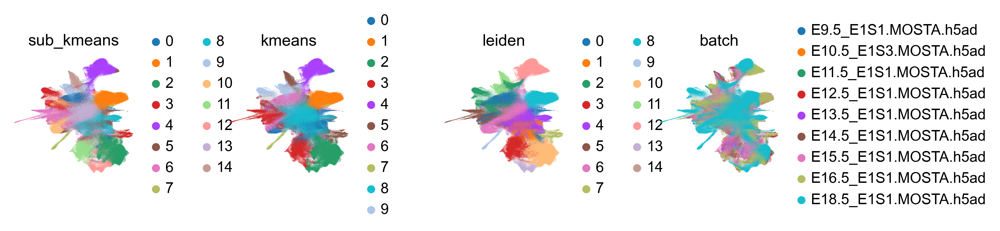

In [14]:
sc.pl.umap(adata_int, color=['sub_kmeans', 'kmeans', 'leiden', 'batch'], ncols=6, wspace=0.5)

In [15]:
batch_names = adata_int.obs.loc[:, 'batch'].unique()
batch_names

['E9.5_E1S1.MOSTA.h5ad', 'E10.5_E1S3.MOSTA.h5ad', 'E11.5_E1S1.MOSTA.h5ad', 'E12.5_E1S1.MOSTA.h5ad', 'E13.5_E1S1.MOSTA.h5ad', 'E14.5_E1S1.MOSTA.h5ad', 'E15.5_E1S1.MOSTA.h5ad', 'E16.5_E1S1.MOSTA.h5ad', 'E18.5_E1S1.MOSTA.h5ad']
Categories (9, object): ['E9.5_E1S1.MOSTA.h5ad', 'E10.5_E1S3.MOSTA.h5ad', 'E11.5_E1S1.MOSTA.h5ad', 'E12.5_E1S1.MOSTA.h5ad', ..., 'E14.5_E1S1.MOSTA.h5ad', 'E15.5_E1S1.MOSTA.h5ad', 'E16.5_E1S1.MOSTA.h5ad', 'E18.5_E1S1.MOSTA.h5ad']

E9.5_E1S1.MOSTA.h5ad


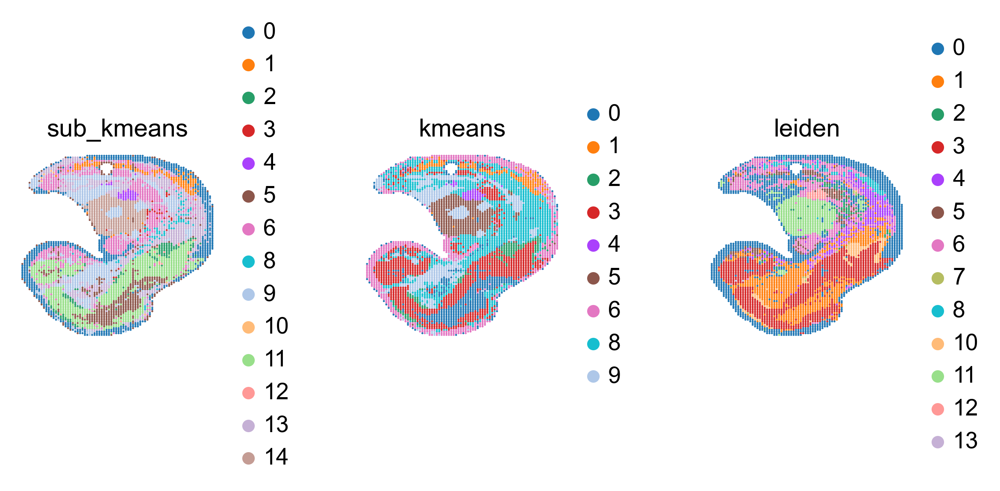

E10.5_E1S3.MOSTA.h5ad


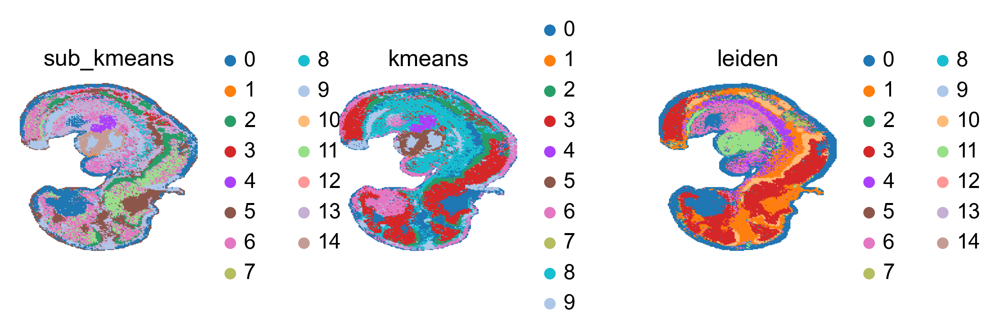

E11.5_E1S1.MOSTA.h5ad


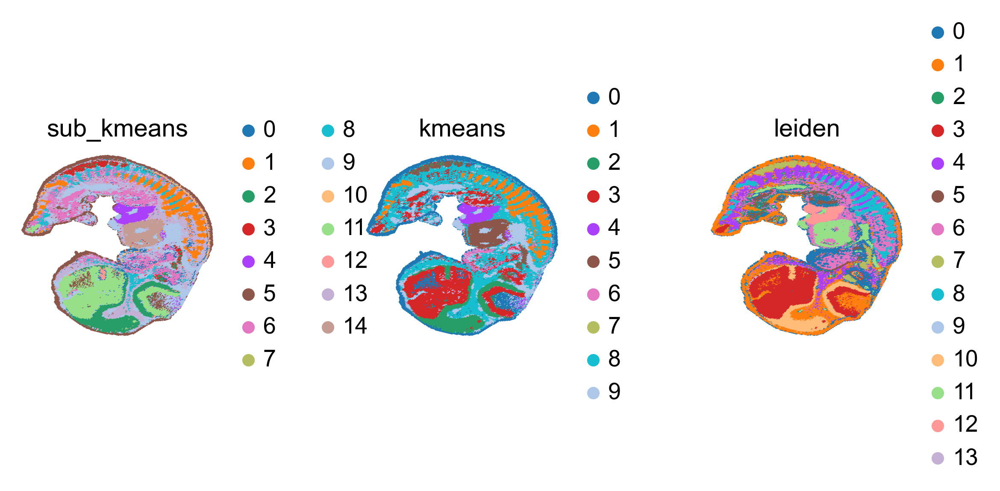

E12.5_E1S1.MOSTA.h5ad


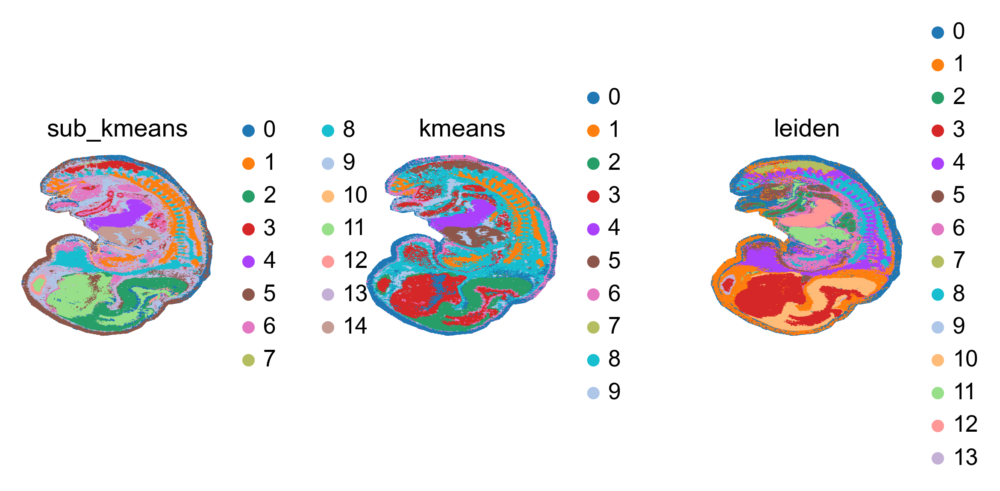

E13.5_E1S1.MOSTA.h5ad


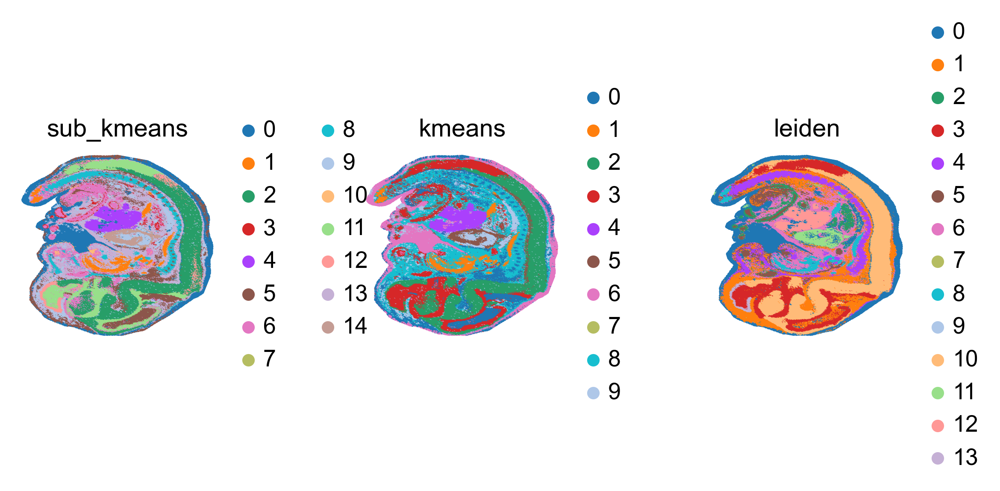

E14.5_E1S1.MOSTA.h5ad


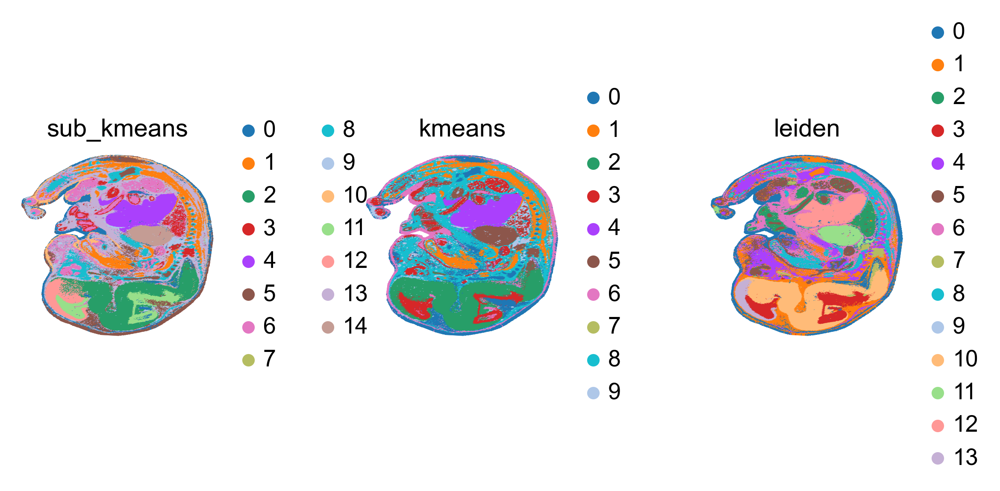

E15.5_E1S1.MOSTA.h5ad


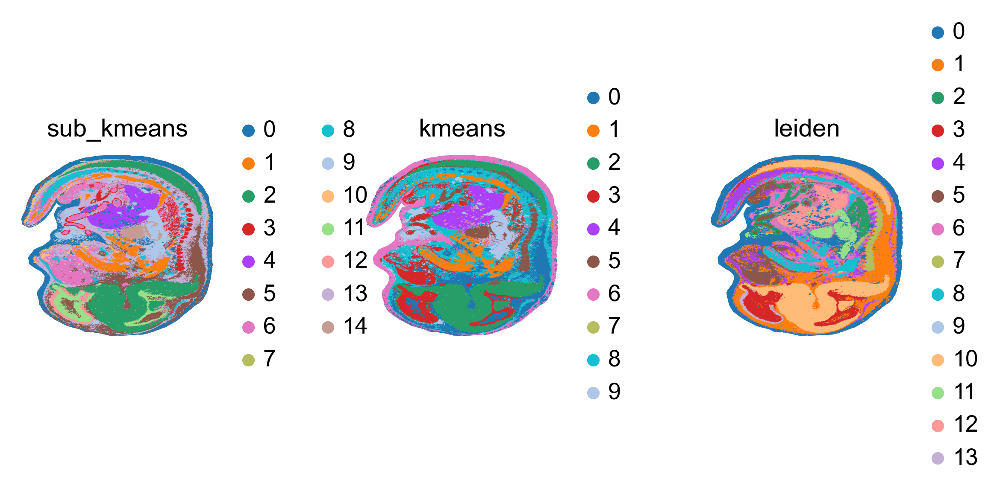

E16.5_E1S1.MOSTA.h5ad


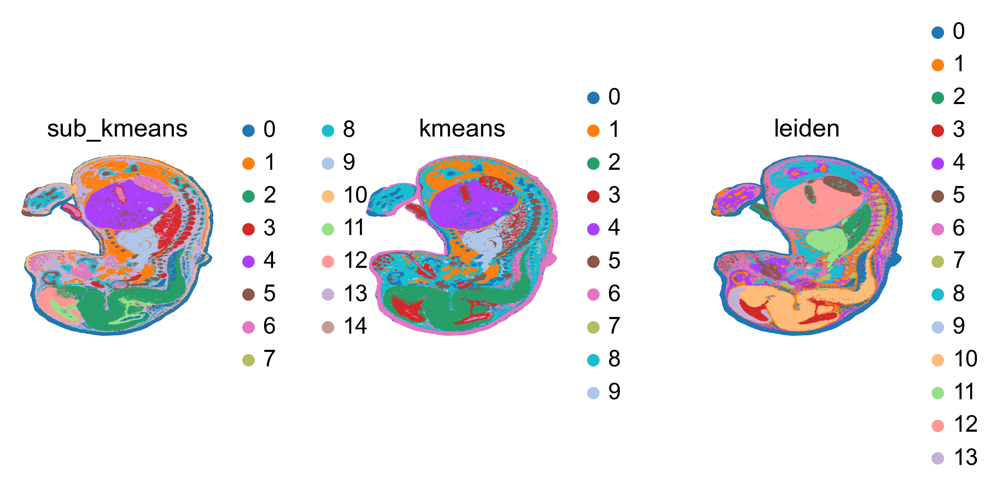

E18.5_E1S1.MOSTA.h5ad


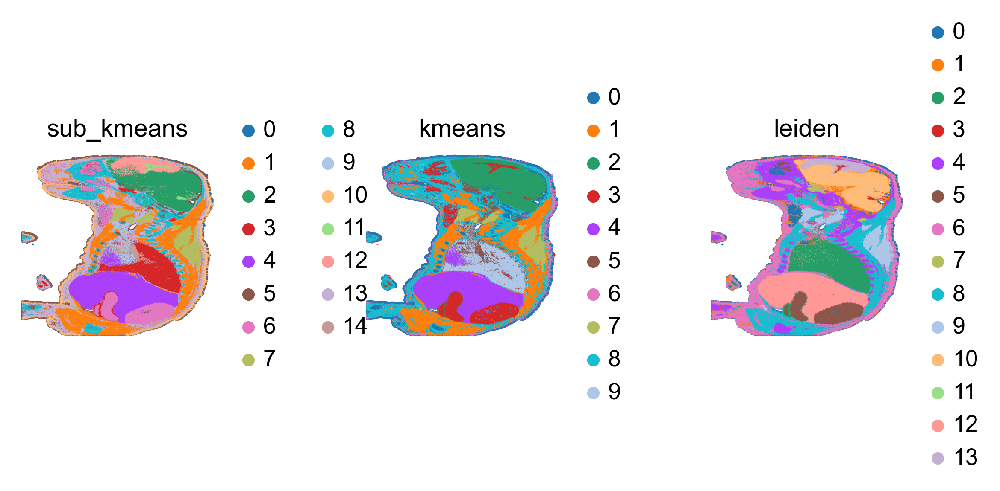

In [16]:
for batch in batch_names:
    temp = adata_int[adata_int.obs.loc[:, 'batch'] == batch, :]
    print(batch)
    sc.pl.embedding(temp, color=['sub_kmeans', 'kmeans', 'leiden'], ncols=5, basis='spatial', size=5, wspace=0.5)
    # break